# Logdet Method Profiling Across Matrix Sizes

This notebook profiles the runtime of different log-determinant strategies used in bayespecon.


The profiling matrices come from a regular polygon grid generated by the `bayespecon.dgp` module. Each size `n` is a grid side length producing an `n × n` rook-contiguity layout with `n²` spatial units; the spatial graph is built from the polygon GeoDataFrame returned by the DGP function.


Methods compared:

- `exact`: symbolic determinant route
- `eigenvalue`: spectral precompute route
- `grid_dense`: dense-grid + spline interpolation (was `dense_grid`/`grid`)
- `grid_sparse`: exact sparse-LU grid (legacy-style sparse-LU, was `sparse_grid`/`full`)
- `sparse_spline`: sparse-LU + spline interpolation (was `spline`)
- `trace_mc`: Monte Carlo trace approximation (was `mc`)
- `grid_ilu`: ILU-based approximate grid (was `ilu`/`ichol`)
- `chebyshev`: Chebyshev polynomial approximation via Clenshaw's algorithm (Pace & LeSage 2004)

For each matrix size, we report:

- **setup time**: build + compile callable logdet function
- **evaluation time**: average cost to evaluate at many rho values

In [1]:
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytensor
import pytensor.tensor as pt
from libpysal import graph

from bayespecon import dgp
from bayespecon.logdet import make_logdet_fn

In [2]:
def make_grid_w(n_side: int) -> np.ndarray:
    """Create a row-standardized rook-contiguity matrix from an n_side x n_side polygon grid.

    Uses ``dgp.simulate_sar`` with ``create_gdf=True`` to generate the polygon
    geometry, then builds a contiguity graph from the returned GeoDataFrame.
    """
    gdf = dgp.simulate_sar(n=n_side, create_gdf=True)
    W = (
        graph.Graph.build_contiguity(gdf, rook=True)
        .transform("r")
        .sparse.toarray()
        .astype(np.float64)
    )
    return W


def compile_logdet_callable(W: np.ndarray, method: str, rho_min: float, rho_max: float):
    """Return a compiled callable f(rho) and its setup time in seconds."""
    t0 = time.perf_counter()
    rho = pt.scalar("rho")
    expr = make_logdet_fn(W, method=method, rho_min=rho_min, rho_max=rho_max)(rho)
    fn = pytensor.function([rho], expr)
    setup_s = time.perf_counter() - t0
    return fn, setup_s


def bench_eval_seconds(fn, rhos: np.ndarray, repeats: int = 5) -> float:
    """Median per-call evaluation latency in microseconds."""
    run_times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        for r in rhos:
            _ = fn(float(r))
        elapsed = time.perf_counter() - t0
        run_times.append(elapsed / len(rhos))
    return float(np.median(run_times))

In [ ]:
@dataclass
class ProfileConfig:
    # Grid side lengths; obs count = n_side². e.g. 6→36, 9→81, 11→121, 13→169, 16→256.
    sizes: tuple[int, ...] = (10, 20, 25, 40, 50, 75)
    methods: tuple[str, ...] = (
        "exact",
        "eigenvalue",
        "grid_dense",
        "grid_sparse",
        "sparse_spline",
        "trace_mc",
        "grid_mc",
        "grid_ilu",
        "chebyshev",
    )
    method_max_n: dict = None
    eval_points: int = 80
    eval_repeats: int = 3
    seed: int = 2026

    def __post_init__(self):
        if self.method_max_n is None:
            self.method_max_n = {
                "exact": 20,
                "eigenvalue": 75,
                "grid_dense": 40,
                "grid_sparse": 75,
                "sparse_spline": 75,
                "trace_mc": 75,
                "grid_ilu": 75,
                "chebyshev": 75,
                "grid_mc": 75,
            }


cfg = ProfileConfig()

# spline/mc are defined on nonnegative rho ranges; others can use symmetric ranges.
method_rho_bounds = {
    "exact": (-0.95, 0.95),
    "eigenvalue": (-0.95, 0.95),
    "grid_dense": (-0.95, 0.95),
    "grid_sparse": (-0.95, 0.95),
    "grid_ilu": (-0.95, 0.95),
    "sparse_spline": (1e-5, 0.95),
    "trace_mc": (1e-5, 0.95),
    "chebyshev": (-0.95, 0.95),
    "grid_mc": (1e-5, 0.95),
}

results = []
skipped = []

for n in cfg.sizes:
    W = make_grid_w(n_side=n)
    print(f"Profiling n_side={n} ({n * n} obs)...")
    for method in cfg.methods:
        if n > cfg.method_max_n[method]:
            skipped.append(
                {
                    "n_side": n,
                    "n_obs": n * n,
                    "method": method,
                    "reason": "above method_max_n cap",
                }
            )
            continue

        rho_min, rho_max = method_rho_bounds[method]
        rho_grid = np.linspace(rho_min, rho_max, cfg.eval_points)

        try:
            fn, setup_s = compile_logdet_callable(
                W, method, rho_min=rho_min, rho_max=rho_max
            )
            eval_s = bench_eval_seconds(fn, rho_grid, repeats=cfg.eval_repeats)
            results.append(
                {
                    "n_side": n,
                    "n_obs": n * n,
                    "method": method,
                    "rho_min": rho_min,
                    "rho_max": rho_max,
                    "setup_ms": 1e3 * setup_s,
                    "eval_us": 1e6 * eval_s,
                }
            )
        except Exception as exc:
            skipped.append(
                {
                    "n_side": n,
                    "n_obs": n * n,
                    "method": method,
                    "reason": f"failed: {type(exc).__name__}: {exc}",
                }
            )

res = pd.DataFrame(results).sort_values(["method", "n_obs"]).reset_index(drop=True)
if not res.empty:
    res["total_ms"] = res["setup_ms"] + (res["eval_us"] * cfg.eval_points / 1e3)
res

Profiling n_side=10 (100 obs)...
Profiling n_side=20 (400 obs)...
Profiling n_side=25 (625 obs)...
Profiling n_side=40 (1600 obs)...
Profiling n_side=50 (2500 obs)...
Profiling n_side=75 (5625 obs)...


,n_side,n_obs,method,rho_min,rho_max,setup_ms,eval_us,total_ms
0,10,100,chebyshev,-0.95,0.95,78.925625,2.380201,79.116041
1,20,400,chebyshev,-0.95,0.95,93.322417,2.109888,93.491208
2,25,625,chebyshev,-0.95,0.95,256.969875,2.479175,257.168209
3,40,1600,chebyshev,-0.95,0.95,482.985875,2.042713,483.149292
4,50,2500,chebyshev,-0.95,0.95,601.257666,2.256248,601.438166
5,75,5625,chebyshev,-0.95,0.95,675.810625,2.135939,675.981500
6,10,100,eigenvalue,-0.95,0.95,23.776542,2.963026,24.013584
7,20,400,eigenvalue,-0.95,0.95,24.920000,3.947923,25.235834
8,25,625,eigenvalue,-0.95,0.95,66.777667,5.096875,67.185417
9,40,1600,eigenvalue,-0.95,0.95,411.143333,8.311975,411.808291


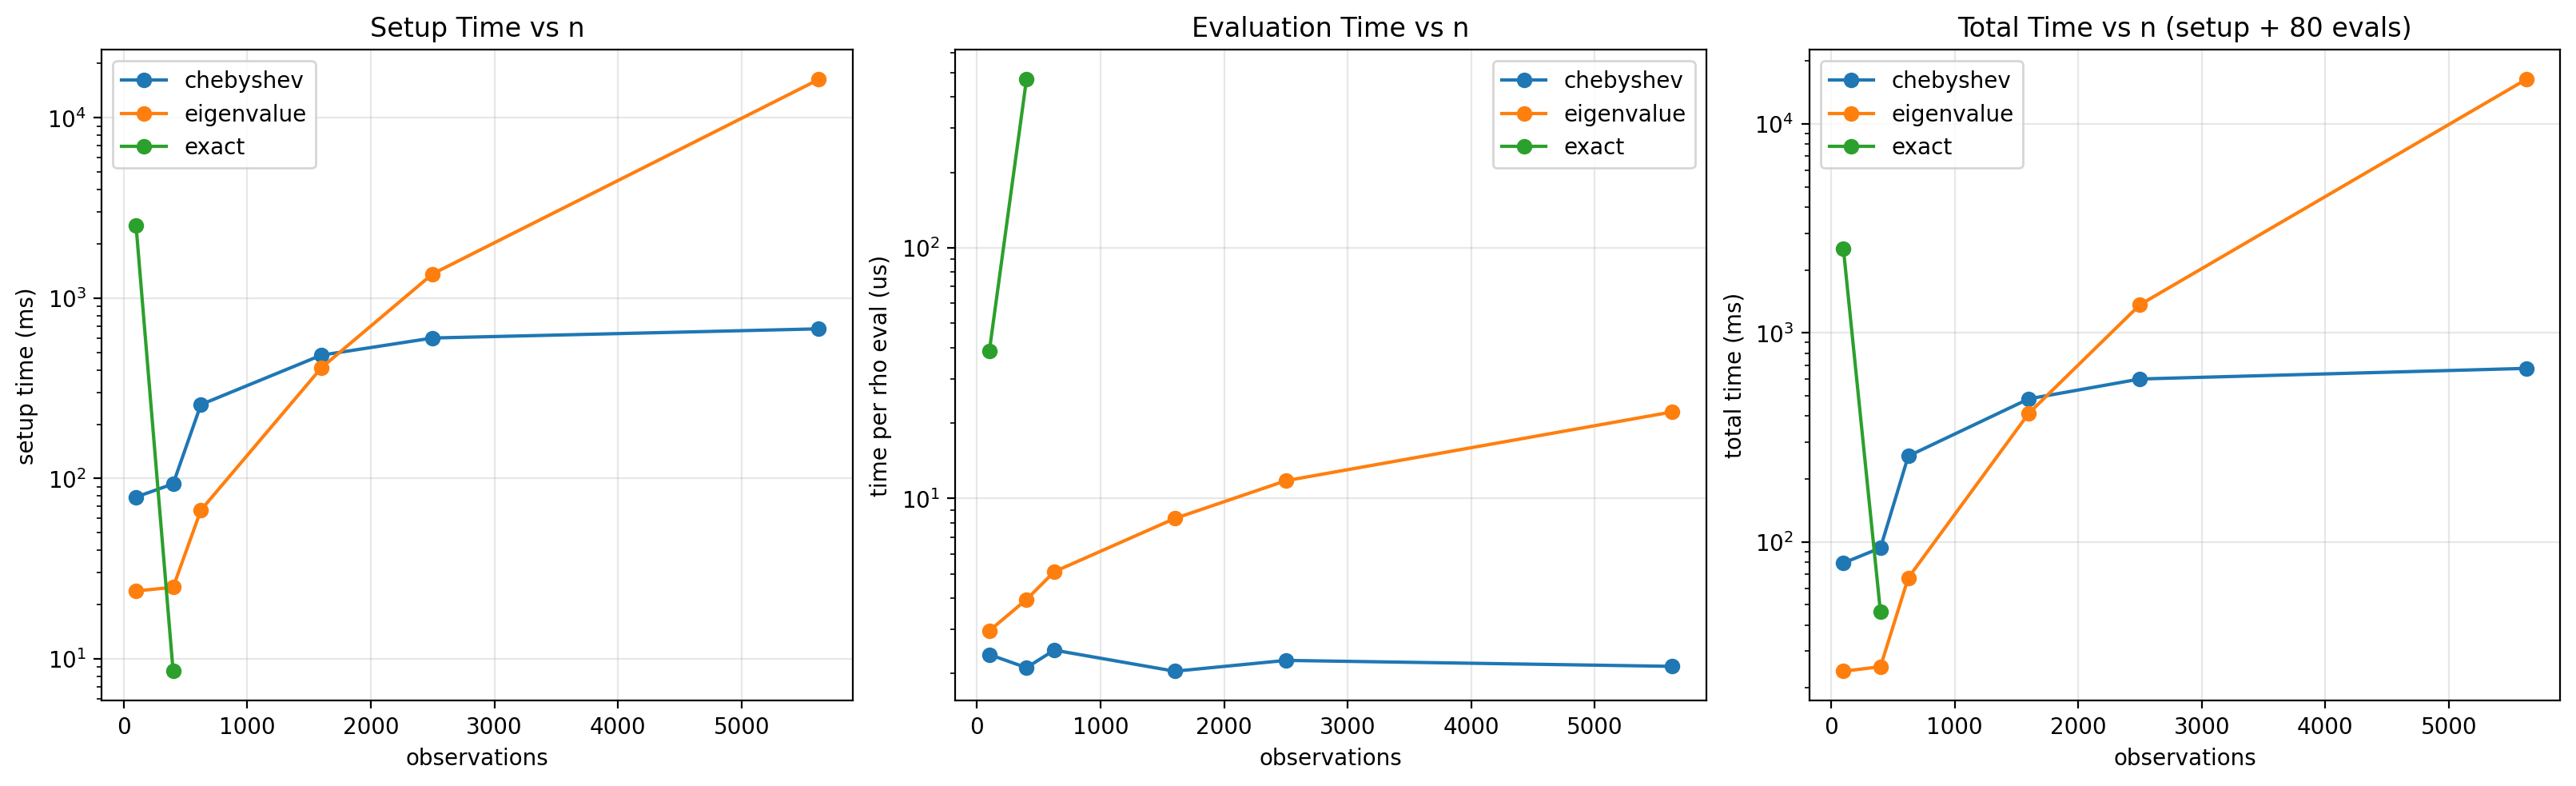

In [4]:
if res.empty:
    raise RuntimeError("No profiling results were generated.")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

for method, grp in res.groupby("method"):
    grp = grp.sort_values("n_obs")
    axes[0].plot(grp["n_obs"], grp["setup_ms"], marker="o", label=method)
    axes[1].plot(grp["n_obs"], grp["eval_us"], marker="o", label=method)
    axes[2].plot(grp["n_obs"], grp["total_ms"], marker="o", label=method)

axes[0].set_title("Setup Time vs n")
axes[0].set_xlabel("observations")
axes[0].set_ylabel("setup time (ms)")
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Evaluation Time vs n")
axes[1].set_xlabel("observations")
axes[1].set_ylabel("time per rho eval (us)")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

axes[2].set_title(f"Total Time vs n (setup + {cfg.eval_points} evals)")
axes[2].set_xlabel("observations")
axes[2].set_ylabel("total time (ms)")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.legend()

plt.show()

In [5]:
summary = res.pivot_table(
    index="n_obs", columns="method", values=["setup_ms", "eval_us", "total_ms"]
).sort_index()
display(summary)

if skipped:
    skipped_df = (
        pd.DataFrame(skipped).sort_values(["n_side", "method"]).reset_index(drop=True)
    )
    print("Skipped combinations (due to safety caps or failures):")
    display(skipped_df)

eval_us                           setup_ms                            \
method chebyshev eigenvalue       exact   chebyshev    eigenvalue       exact   
n_obs                                                                           
100     2.380201   2.963026   38.814588   78.925625     23.776542  2528.53200   
400     2.109888   3.947923  469.876564   93.322417     24.920000     8.53375   
625     2.479175   5.096875         NaN  256.969875     66.777667         NaN   
1600    2.042713   8.311975         NaN  482.985875    411.143333         NaN   
2500    2.256248  11.766661         NaN  601.257666   1363.441083         NaN   
5625    2.135939  22.127599         NaN  675.810625  16330.980542         NaN   

          total_ms                             
method   chebyshev    eigenvalue        exact  
n_obs                                          
100      79.116041     24.013584  2531.637167  
400      93.491208     25.235834    46.123875  
625     257.168209     67.185417          NaN  
1600    483.149292    411.808291          NaN  
2500    601.438166   1364.382416          NaN  
5625    675.981500  16332.750750          NaN

Skipped combinations (due to safety caps or failures):


,n_side,n_obs,method,reason
0,10,100,dense_grid,failed: ValueError: Unknown logdet method: 'de...
1,10,100,ilu,failed: ValueError: Unknown logdet method: 'il...
2,10,100,mc,failed: ValueError: Unknown logdet method: 'mc...
3,10,100,mc_poly,failed: ValueError: Unknown logdet method: 'mc...
4,10,100,sparse_grid,failed: ValueError: Unknown logdet method: 'sp...
5,10,100,spline,failed: ValueError: Unknown logdet method: 'sp...
6,20,400,dense_grid,failed: ValueError: Unknown logdet method: 'de...
7,20,400,ilu,failed: ValueError: Unknown logdet method: 'il...
8,20,400,mc,failed: ValueError: Unknown logdet method: 'mc...
9,20,400,mc_poly,failed: ValueError: Unknown logdet method: 'mc...


## Coefficient and Fit-Time Comparison Across Logdet Methods

This section uses a regular polygon grid generated by `bayespecon.dgp` to simulate one SAR dataset, maps the simulated response, and estimates the same SAR model using each `logdet_method`.

We compare:

- posterior mean coefficients (`rho`, `beta_0`, `beta_1`, `beta_2`)
- total wall-clock time to estimate each model

To keep this section runnable in docs contexts, sampling is intentionally modest.


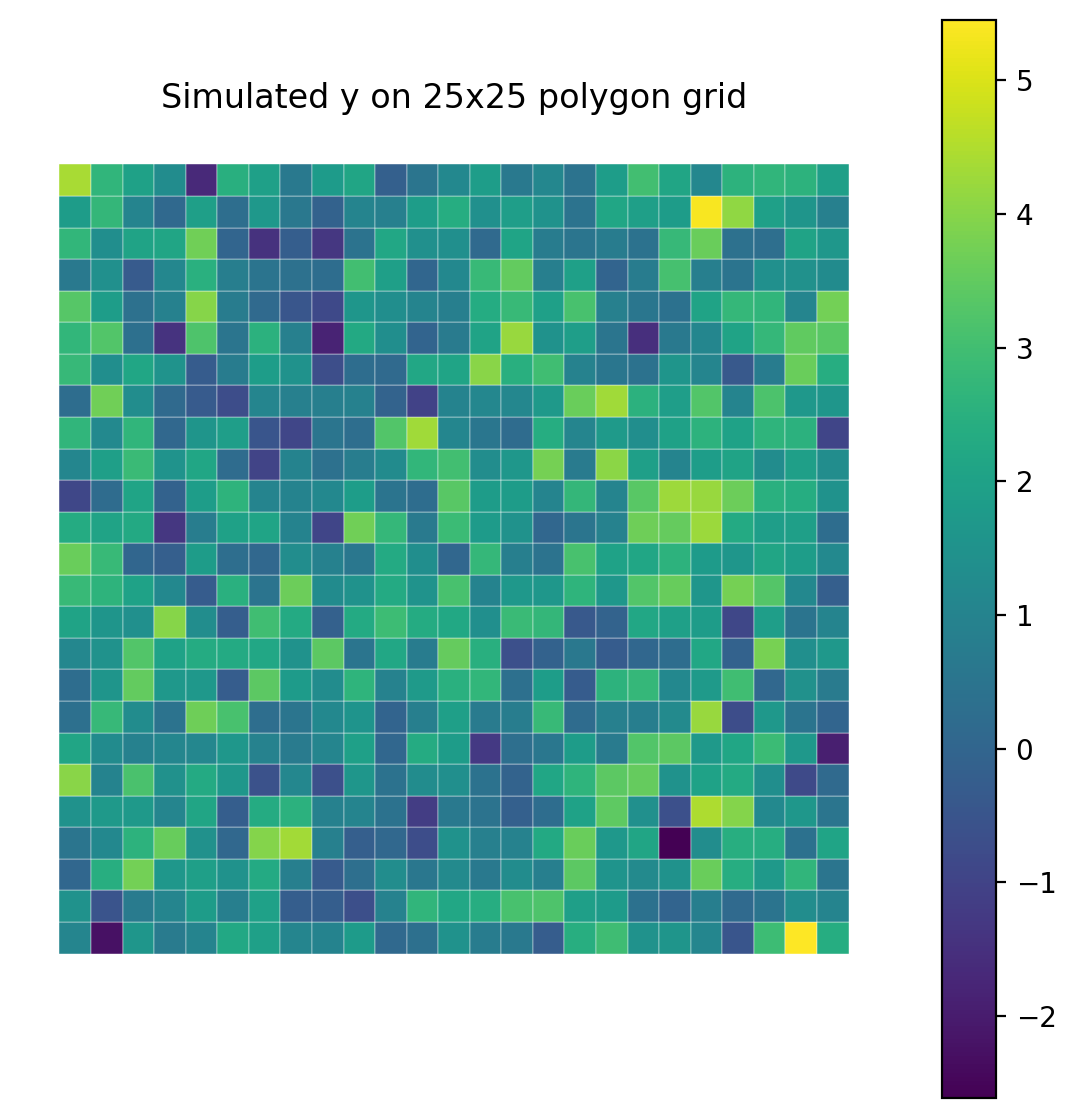

Initializing NUTS using jitter+adapt_diag...


Estimating SAR with method=eigenvalue...


Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...


Estimating SAR with method=dense_grid...
Estimating SAR with method=sparse_grid...
Estimating SAR with method=mc_poly...
Estimating SAR with method=ilu...
Estimating SAR with method=chebyshev...


Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.


,method,total_time_s,rho,beta_0,beta_1,beta_2,error,rho_true,abs_err_rho,beta_0_true,abs_err_beta_0,beta_1_true,abs_err_beta_1,beta_2_true,abs_err_beta_2,delta_vs_eigen_rho,delta_vs_eigen_beta_0,delta_vs_eigen_beta_1,delta_vs_eigen_beta_2
0,eigenvalue,1.374450,0.381457,0.884519,0.808531,-0.518253,NaN,0.35,0.031457,1.0,0.115481,0.8,0.008531,-0.5,0.018253,0.000000,0.000000,0.000000,0.000000
1,chebyshev,1.699094,0.380549,0.885094,0.811359,-0.519605,NaN,0.35,0.030549,1.0,0.114906,0.8,0.011359,-0.5,0.019605,-0.000908,0.000575,0.002827,-0.001352
2,dense_grid,NaN,NaN,NaN,NaN,NaN,ValueError: Unknown logdet method: 'dense_grid...,0.35,NaN,1.0,NaN,0.8,NaN,-0.5,NaN,NaN,NaN,NaN,NaN
3,sparse_grid,NaN,NaN,NaN,NaN,NaN,ValueError: Unknown logdet method: 'sparse_gri...,0.35,NaN,1.0,NaN,0.8,NaN,-0.5,NaN,NaN,NaN,NaN,NaN
4,mc_poly,NaN,NaN,NaN,NaN,NaN,ValueError: Unknown logdet method: 'mc_poly'. ...,0.35,NaN,1.0,NaN,0.8,NaN,-0.5,NaN,NaN,NaN,NaN,NaN
5,ilu,NaN,NaN,NaN,NaN,NaN,ValueError: Unknown logdet method: 'ilu'. Vali...,0.35,NaN,1.0,NaN,0.8,NaN,-0.5,NaN,NaN,NaN,NaN,NaN


In [ ]:
from bayespecon import SAR

def simulate_sar_data(n_side: int = 16, seed: int = 2026):
    """Simulate SAR data on an n_side x n_side polygon grid using the DGP module."""
    rng = np.random.default_rng(seed)
    beta_true = np.array([1.0, 0.8, -0.5], dtype=np.float64)
    rho_true = 0.35
    sigma_true = 0.7

    gdf = dgp.simulate_sar(
    "        n=n_side,","        rho=rho_true,","        beta=beta_true,","        sigma=sigma_true,","        rng=rng,","        create_gdf=True,",    "    )","    # Keep the SAR parameterization consistent with model assumptions.","    W_graph = graph.Graph.build_contiguity(gdf, rook=True).transform(\"r\")","    y = gdf[\"y\"].to_numpy()","    X_cols = [c for c in gdf.columns if c.startswith(\"X_\")]","    X = gdf[X_cols].to_numpy()","    return gdf, y, X, W_graph, rho_true, beta_true","","","def fit_sar_for_method(","    y,","    X,","    W,","    method: str,","    draws: int = 400,","    tune: int = 400,","    seed: int = 2026,","    rho_lower: float = 1e-5,","    rho_upper: float = 0.95,",):","    """Fit SAR with a specific logdet method and return posterior means + runtime."""","    t0 = time.perf_counter()","","    model = SAR(","        y=y,","        X=X,","        W=W,","        logdet_method=method,","        priors={\"rho_lower\": rho_lower, \"rho_upper\": rho_upper},","    )","    idata = model.fit(","        draws=draws,","        tune=tune,","        chains=2,","        cores=1,","        random_seed=seed,","        target_accept=0.95,","        progressbar=False,","        compute_convergence_checks=False,","    )","","    elapsed_s = time.perf_counter() - t0","    beta_mean = idata.posterior[\"beta\"].mean((\"chain\", \"draw\")).to_numpy()","    rho_mean = float(idata.posterior[\"rho\"].mean((\"chain\", \"draw\")).to_numpy())","","    return {","        \"method\": method,","        \"total_time_s\": elapsed_s,","        \"rho\": rho_mean,","        \"beta_0\": float(beta_mean[0]),","        \"beta_1\": float(beta_mean[1]),","        \"beta_2\": float(beta_mean[2]),","    }","","","methods_for_model = [","    \"eigenvalue\",","    \"grid_dense\",","    \"grid_sparse\",","    \"grid_mc\",","    \"grid_ilu\",","    \"chebyshev\",","]","gdf_model, y_model, X_model, W_model, rho_true, beta_true = simulate_sar_data(n_side=25)","","fig, ax = plt.subplots(1, 1, figsize=(7, 7))","gdf_model.plot(","    column=\"y\", cmap=\"viridis\", legend=True, linewidth=0.15, edgecolor=\"white\", ax=ax",)","ax.set_title(\"Simulated y on 25x25 polygon grid\")","ax.set_axis_off()","plt.show()","","model_rows = []","for m in methods_for_model:","    print(f\"Estimating SAR with method={m}...\")","    try:","        model_rows.append(fit_sar_for_method(y_model, X_model, W_model, method=m))","    except Exception as exc:","        model_rows.append(","            {","                \"method\": m,","                \"total_time_s\": np.nan,","                \"rho\": np.nan,","                \"beta_0\": np.nan,","                \"beta_1\": np.nan,","                \"beta_2\": np.nan,","                \"error\": f\"{type(exc).__name__}: {exc}\",","            }",    )","","coef_compare = pd.DataFrame(model_rows)","coef_compare = coef_compare.sort_values(\"total_time_s\", na_position=\"last\").reset_index(","    drop=True",)","","coef_compare[\"rho_true\"] = rho_true","coef_compare[\"abs_err_rho\"] = (coef_compare[\"rho\"] - rho_true).abs()","for j, btrue in enumerate(beta_true):","    coef_compare[f\"beta_{j}_true\"] = btrue","    coef_compare[f\"abs_err_beta_{j}\"] = (coef_compare[f\"beta_{j}\"] - btrue).abs()","","if \"eigenvalue\" in coef_compare[\"method\"].values:","    base = coef_compare.loc[","        coef_compare[\"method\"] == \"eigenvalue\", [\"rho\", \"beta_0\", \"beta_1\", \"beta_2\"]", "    ].iloc[0]","    for col in [\"rho\", \"beta_0\", \"beta_1\", \"beta_2\"]:","        coef_compare[f\"delta_vs_eigen_{col}\"] = coef_compare[col] - base[col]","","display(coef_compare)

## Notes

- `exact` is expected to scale poorly and is intentionally capped at smaller n in this notebook.
- `eigenvalue` usually has moderate setup cost and very fast repeated evaluations.
- `grid_dense` has an upfront grid-construction cost but can be competitive for repeated evaluation scenarios (was `dense_grid`/`grid`).
- `grid_sparse` and `sparse_spline` are sparse-LU variants inspired by the legacy toolbox routines (were `full` and `int`).
- `trace_mc` is stochastic and may vary slightly run-to-run unless random seeds are fixed.
- `grid_ilu` uses an ILU approximation that can trade precision for speed depending on sparsity (was `ilu`/`ichol`).
- `chebyshev` uses Chebyshev polynomial approximation via Clenshaw's algorithm (Pace & LeSage 2004). It pre-computes coefficients at Chebyshev nodes (O(n³) for eigenvalue path, O(R·n·m) for MC path) and then evaluates in O(m) per call. It supports negative rho ranges, unlike `sparse_spline` and `trace_mc`.
- **Parameter ranges:** `sparse_spline` and `trace_mc` are profiled on a nonnegative range (`rho in [1e-5, 0.95]`), while `exact`, `eigenvalue`, `grid_dense`, `grid_sparse`, `grid_ilu`, and `chebyshev` are profiled on a symmetric range (`rho in [-0.95, 0.95]`).
- Adjust `ProfileConfig.sizes` and `method_max_n` for deeper stress tests.

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [rho, beta, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 1 seconds.


ValueError: Unknown logdet method: 'dense_grid'. Valid options: chebyshev, eigenvalue, exact, grid_dense, grid_ilu, grid_mc, grid_sparse, sparse_spline, trace_mc.

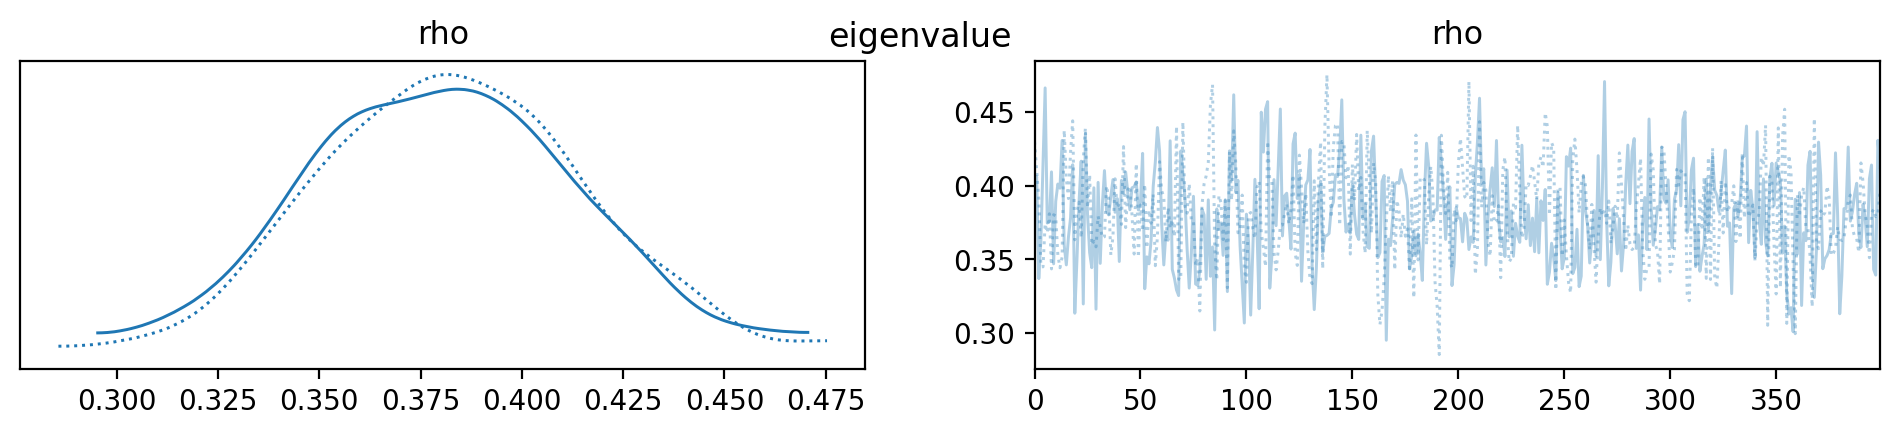

In [7]:
import arviz as az
import pandas as pd

# Assuming you have a list of inference data objects (idata) for each method,
# or you can refit/collect them as needed. If you only have the summary DataFrames,
# adapt the code to use those directly.

ess_rows = []
for i, m in enumerate(methods_for_model):
    model = SAR(
        y=y_model,
        X=X_model,
        W=W_model,
        logdet_method=m,
        priors={"rho_lower": 1e-5, "rho_upper": 0.95},
    )
    idata = model.fit(
        draws=400,
        tune=400,
        chains=2,
        cores=1,
        random_seed=2026,
        target_accept=0.95,
        progressbar=False,
        compute_convergence_checks=False,
    )
    summary = az.summary(idata, var_names=["rho"])
    ess = summary.loc["rho", "ess_bulk"]
    ess_rows.append({"method": m, "ess_rho": ess})
    az.plot_trace(idata, var_names=["rho"], compact=True, legend=False)
    plt.suptitle(m)

ess_df = pd.DataFrame(ess_rows)
display(ess_df)

ess_df.set_index("method")["ess_rho"].plot.bar(
    ylabel="ESS (rho)", title="Effective Sample Size for rho by Logdet Method"
)

## Method selection policy

1. Default for most work

- Use chebyshev.
- Reason: good speed, stable behavior, and supports both negative and positive rho ranges.

2.Exploratory runs where speed is most important

- If rho is constrained to nonnegative values, use mc.
- Keep this for quick iteration, model search, and early diagnostics.

3. Deterministic interpolation alternative

- If rho is nonnegative and you want deterministic behavior, use spline.
- Only use when prior bounds are fully inside the interpolation interval.

4. Final reporting and publication runs

- Prefer chebyshev.
- If using mc or spline, validate against chebyshev on the same data and priors.

5. Guardrails
- If prior includes negative rho, do not use mc or spline.
- Avoid switching methods mid-comparison unless you explicitly document it.
- Record method choice and rho bounds in every benchmark or model report.


Suggested defaults by stage

Development: mc (nonnegative rho only), otherwise chebyshev.
Pre-final validation: chebyshev.
Final results: chebyshev, or mc/spline with chebyshev cross-check.